In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns = None
import warnings

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s4e4/train.csv')
train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [3]:
test = pd.read_csv('/kaggle/input/playground-series-s4e4/test.csv')
test.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11.0
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11.0
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6.0
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10.0
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9.0


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151026 entries, 0 to 60410
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              151026 non-null  int64  
 1   Sex             151026 non-null  object 
 2   Length          151026 non-null  float64
 3   Diameter        151026 non-null  float64
 4   Height          151026 non-null  float64
 5   Whole weight    151026 non-null  float64
 6   Whole weight.1  151026 non-null  float64
 7   Whole weight.2  151026 non-null  float64
 8   Shell weight    151026 non-null  float64
 9   Rings           90615 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 12.7+ MB


In [6]:
combined.dtypes

id                  int64
Sex                object
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Whole weight.1    float64
Whole weight.2    float64
Shell weight      float64
Rings             float64
dtype: object

In [7]:
combined.isnull().notnull()/len(combined*100)

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
1,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
2,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
3,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
4,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
...,...,...,...,...,...,...,...,...,...,...
60406,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
60407,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
60408,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007
60409,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007


In [8]:
combined.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings'],
      dtype='object')

In [9]:
combined.corr

<bound method DataFrame.corr of            id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0           0   F   0.550     0.430   0.150        0.7715          0.3285   
1           1   F   0.630     0.490   0.145        1.1300          0.4580   
2           2   I   0.160     0.110   0.025        0.0210          0.0055   
3           3   M   0.595     0.475   0.150        0.9145          0.3755   
4           4   I   0.555     0.425   0.130        0.7820          0.3695   
...       ...  ..     ...       ...     ...           ...             ...   
60406  151021   I   0.345     0.260   0.085        0.1775          0.0735   
60407  151022   F   0.525     0.410   0.145        0.8445          0.3885   
60408  151023   I   0.590     0.440   0.155        1.1220          0.3930   
60409  151024   F   0.660     0.525   0.190        1.4935          0.5885   
60410  151025   F   0.430     0.340   0.120        0.4150          0.1525   

       Whole weight.2  Shell weight  Rings 

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,151026.0,75512.500000,43597.595215,0.0000,37756.2500,75512.5000,113268.7500,151025.0000
Length,151026.0,0.517230,0.117974,0.0750,0.4450,0.5450,0.6000,0.8150
Diameter,151026.0,0.401792,0.097804,0.0550,0.3450,0.4250,0.4700,0.6500
Height,151026.0,0.135579,0.038075,0.0000,0.1100,0.1400,0.1600,1.1300
Whole weight,151026.0,0.789446,0.457637,0.0020,0.4195,0.7995,1.0680,2.8255
Whole weight.1,151026.0,0.340958,0.204345,0.0010,0.1775,0.3295,0.4635,1.4880
Whole weight.2,151026.0,0.169421,0.100833,0.0005,0.0865,0.1660,0.2325,0.7600
Shell weight,151026.0,0.225989,0.130052,0.0015,0.1200,0.2250,0.3050,1.0050
Rings,90615.0,9.696794,3.176221,1.0000,8.0000,9.0000,11.0000,29.0000


In [11]:
combined.shape

(151026, 10)

In [12]:
combined.kurt

<bound method DataFrame.kurt of            id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0           0   F   0.550     0.430   0.150        0.7715          0.3285   
1           1   F   0.630     0.490   0.145        1.1300          0.4580   
2           2   I   0.160     0.110   0.025        0.0210          0.0055   
3           3   M   0.595     0.475   0.150        0.9145          0.3755   
4           4   I   0.555     0.425   0.130        0.7820          0.3695   
...       ...  ..     ...       ...     ...           ...             ...   
60406  151021   I   0.345     0.260   0.085        0.1775          0.0735   
60407  151022   F   0.525     0.410   0.145        0.8445          0.3885   
60408  151023   I   0.590     0.440   0.155        1.1220          0.3930   
60409  151024   F   0.660     0.525   0.190        1.4935          0.5885   
60410  151025   F   0.430     0.340   0.120        0.4150          0.1525   

       Whole weight.2  Shell weight  Rings 

In [13]:
combined.skew

<bound method DataFrame.skew of            id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0           0   F   0.550     0.430   0.150        0.7715          0.3285   
1           1   F   0.630     0.490   0.145        1.1300          0.4580   
2           2   I   0.160     0.110   0.025        0.0210          0.0055   
3           3   M   0.595     0.475   0.150        0.9145          0.3755   
4           4   I   0.555     0.425   0.130        0.7820          0.3695   
...       ...  ..     ...       ...     ...           ...             ...   
60406  151021   I   0.345     0.260   0.085        0.1775          0.0735   
60407  151022   F   0.525     0.410   0.145        0.8445          0.3885   
60408  151023   I   0.590     0.440   0.155        1.1220          0.3930   
60409  151024   F   0.660     0.525   0.190        1.4935          0.5885   
60410  151025   F   0.430     0.340   0.120        0.4150          0.1525   

       Whole weight.2  Shell weight  Rings 

<Axes: >

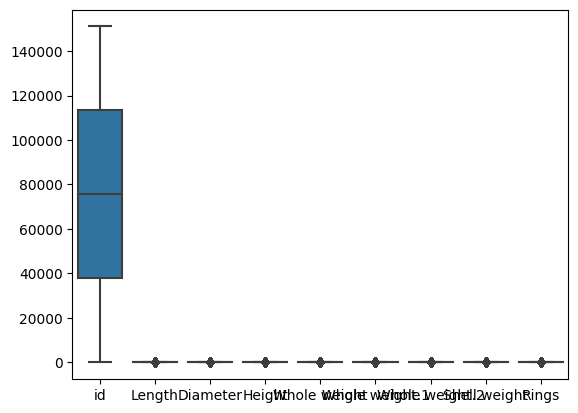

In [14]:
sns.boxplot(combined)

In [15]:
cat_cols = combined.select_dtypes(include='object')

In [17]:
for i in cat_cols:
    print(i)
    (cat_cols[i].value_counts())
    print(''*50)

Sex



In [18]:
num_cols = combined.select_dtypes(include='number')

In [19]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print(''*50)

id

Length

Diameter

Height

Whole weight

Whole weight.1

Whole weight.2

Shell weight

Rings



<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


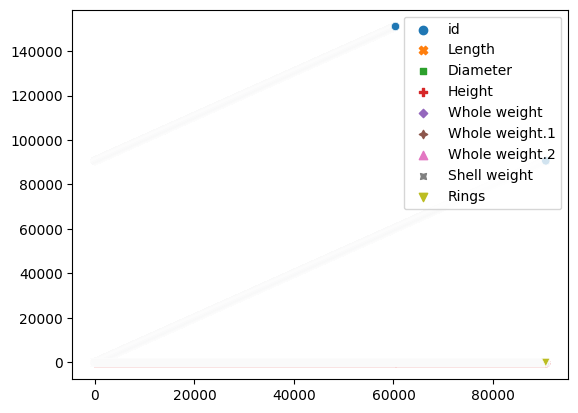

In [32]:
sns.scatterplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

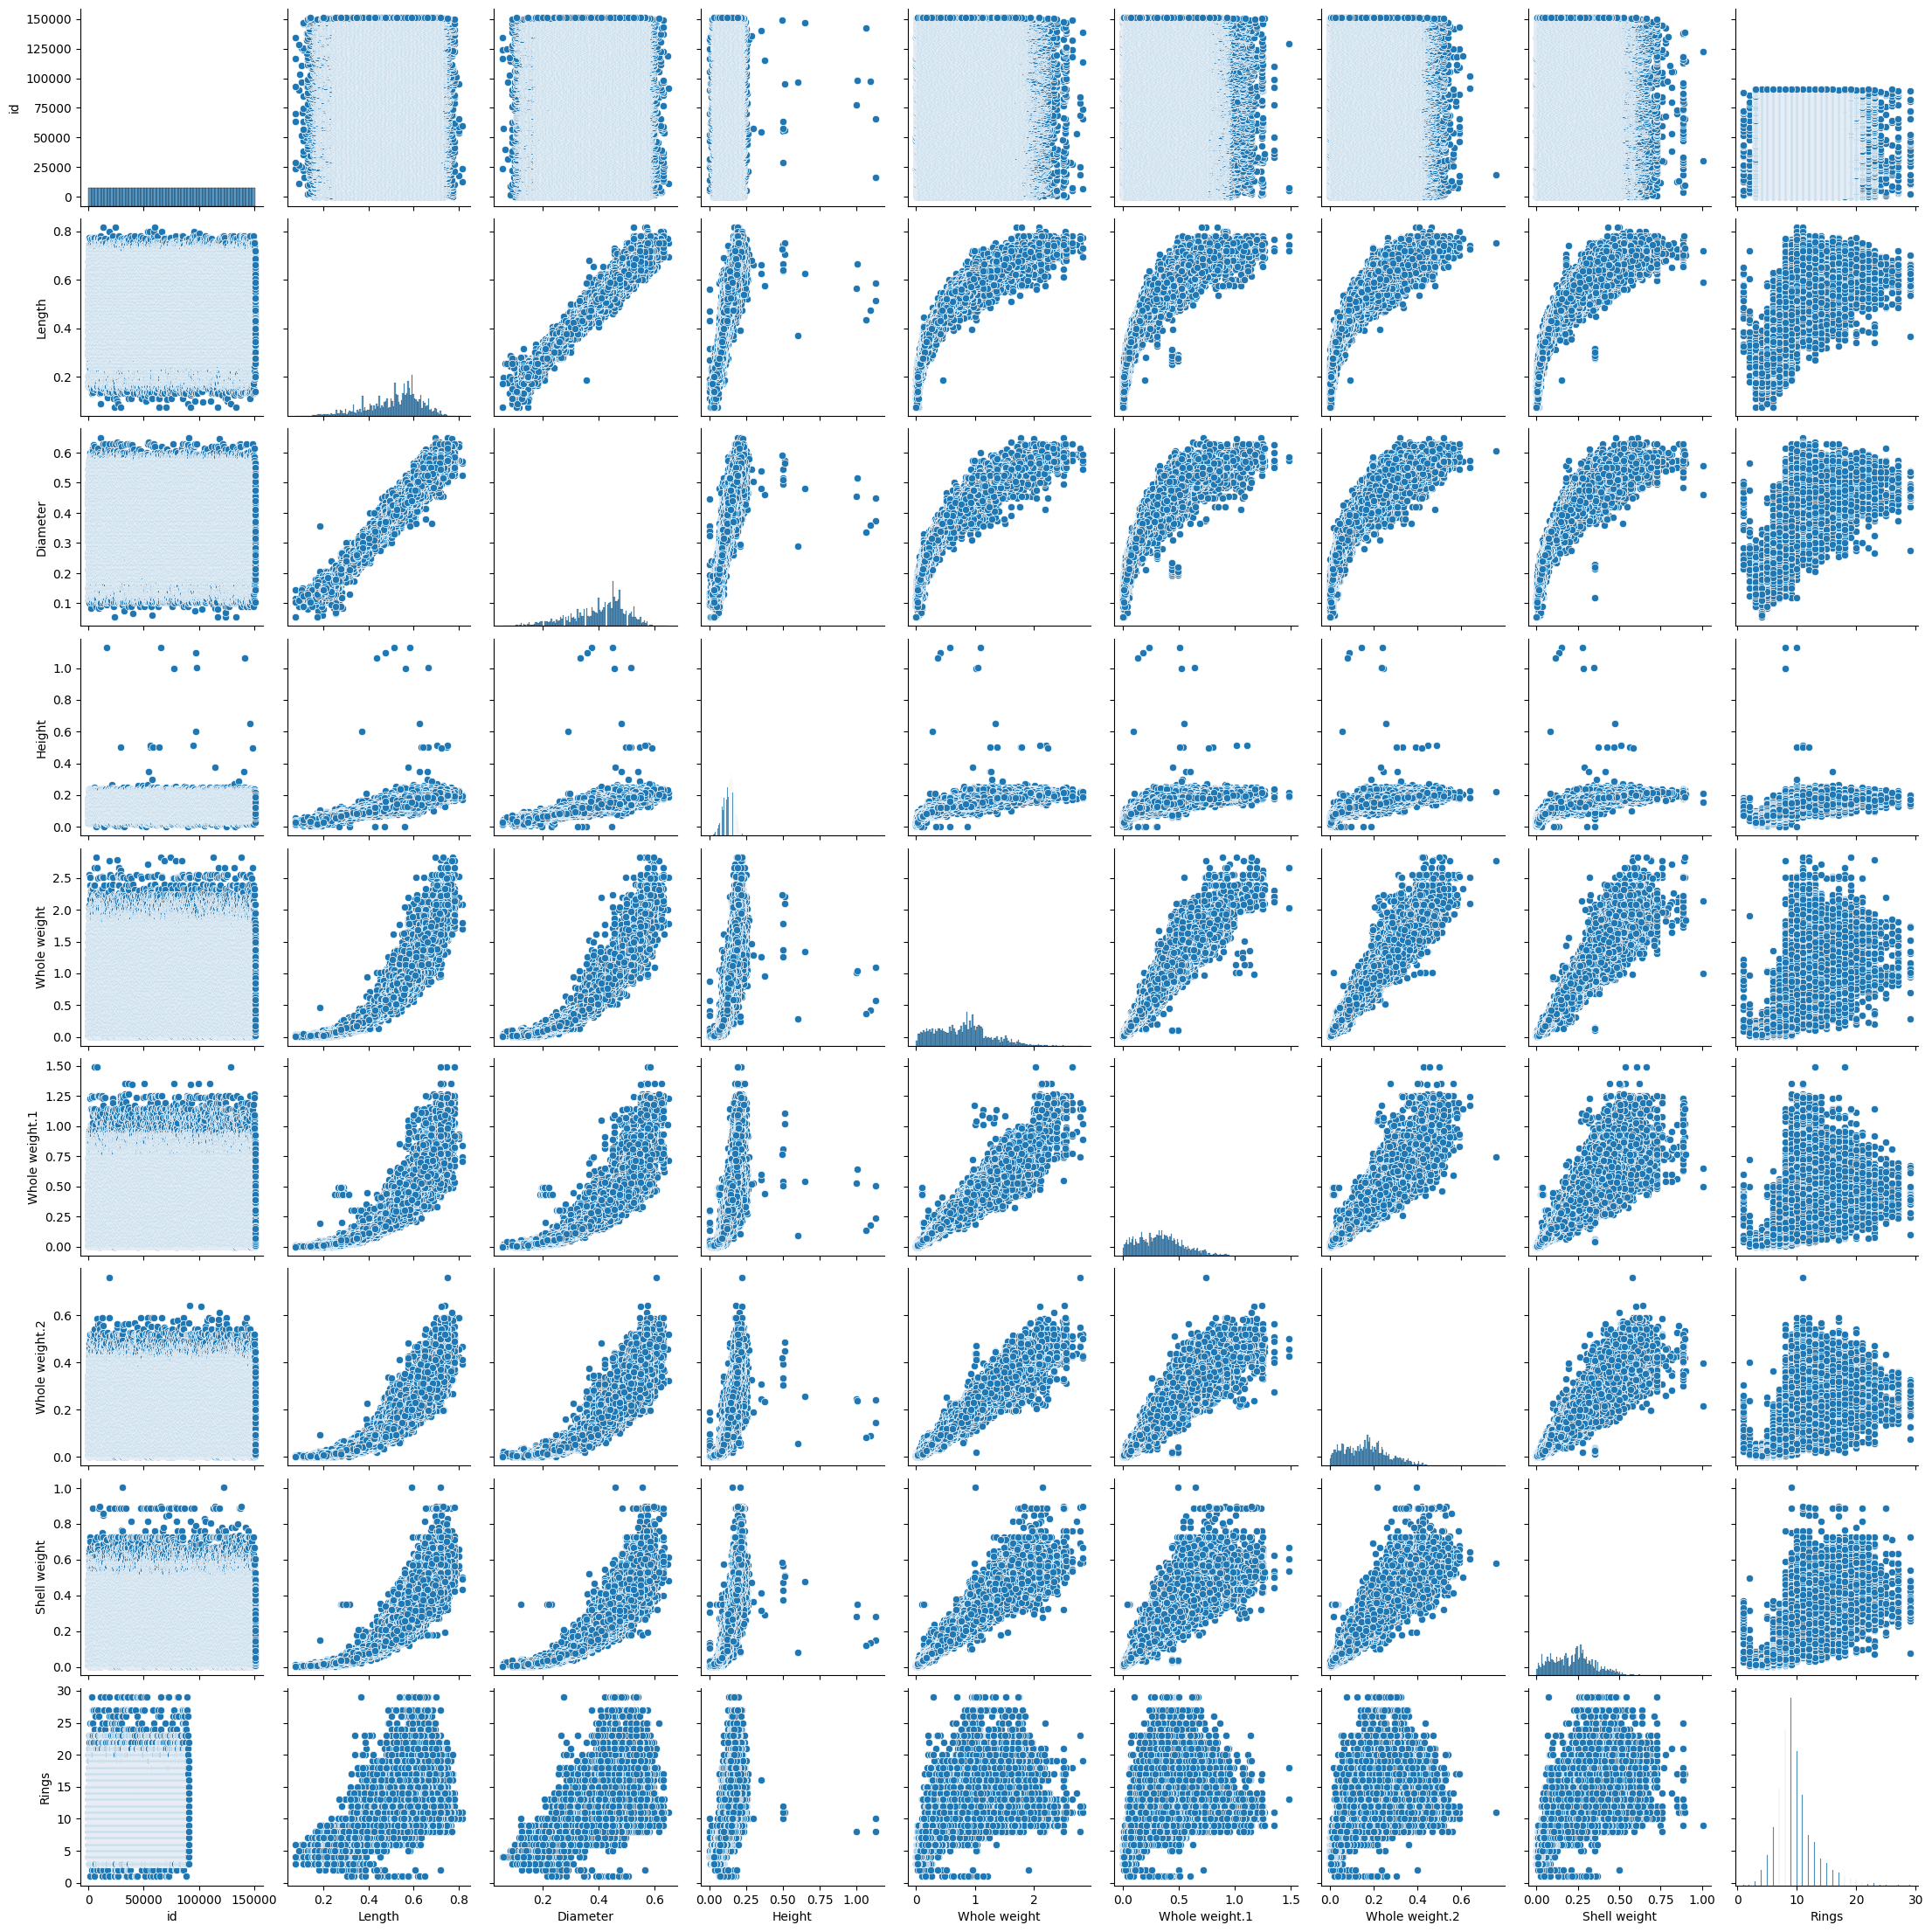

In [21]:
sns.pairplot(combined)

<Axes: >

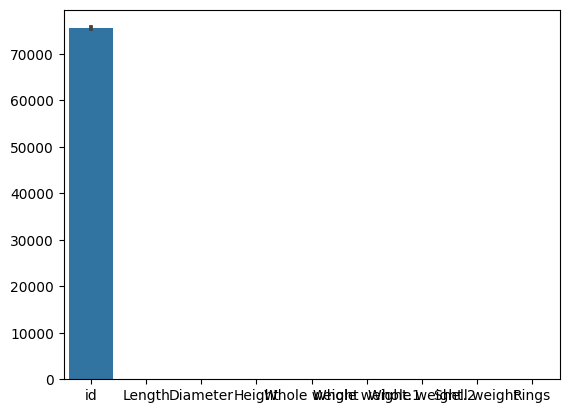

In [23]:
sns.barplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

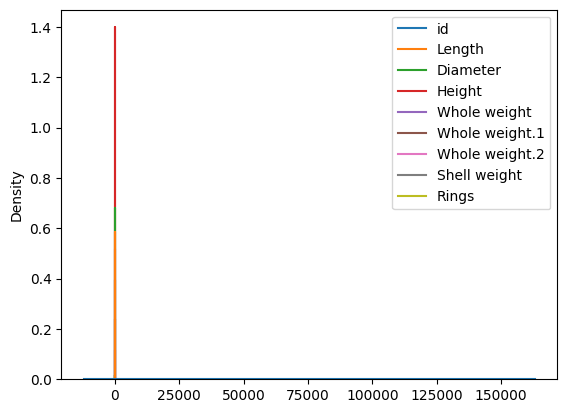

In [24]:
sns.kdeplot(combined)

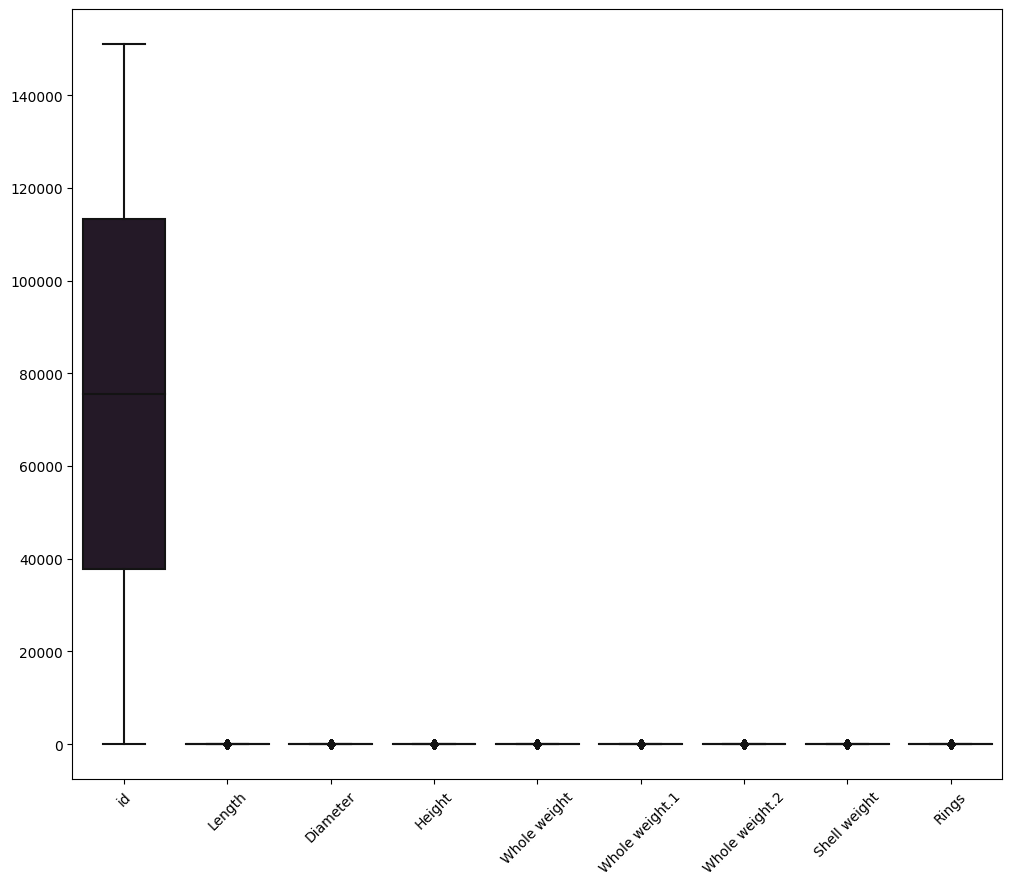

In [26]:
plt.figure(figsize=(12,10))
sns.boxplot(data=combined,palette='mako');
plt.xticks(rotation=45);

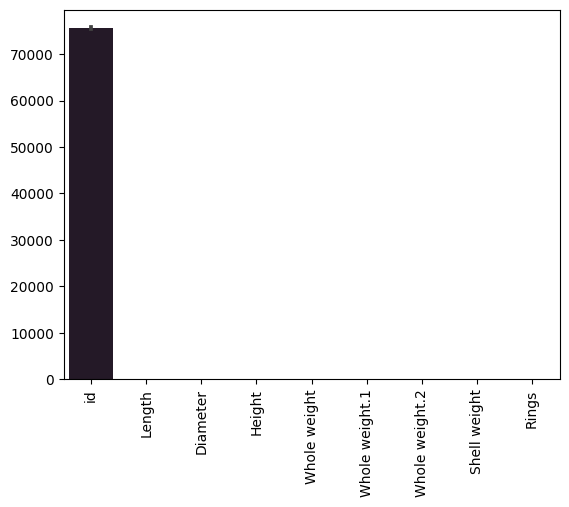

In [27]:
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=90);

(array([-20000.,      0.,  20000.,  40000.,  60000.,  80000., 100000.]),
 [Text(-20000.0, 0, '−20000'),
  Text(0.0, 0, '0'),
  Text(20000.0, 0, '20000'),
  Text(40000.0, 0, '40000'),
  Text(60000.0, 0, '60000'),
  Text(80000.0, 0, '80000'),
  Text(100000.0, 0, '100000')])

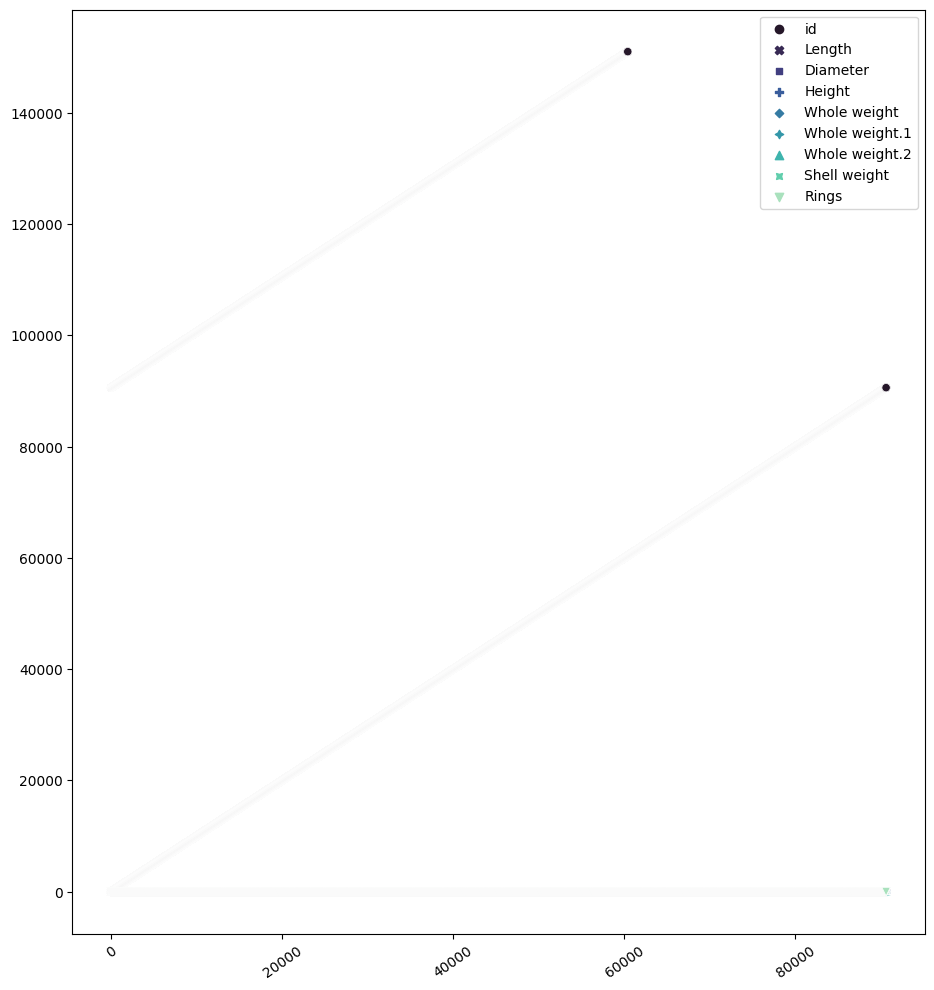

In [28]:
plt.figure(figsize=(11,12))
sns.scatterplot(data=combined,palette='mako');
plt.xticks(rotation = 35)

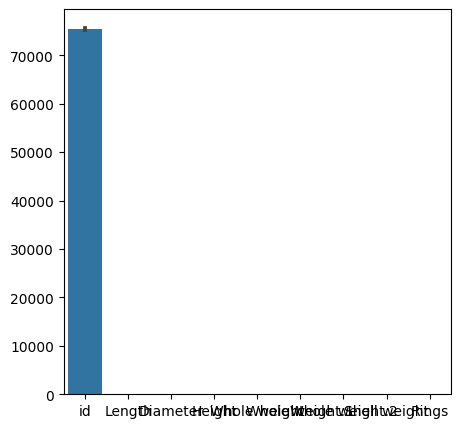

In [29]:
plt.figure(figsize=(5,5))
x = 1
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.barplot(data=combined)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

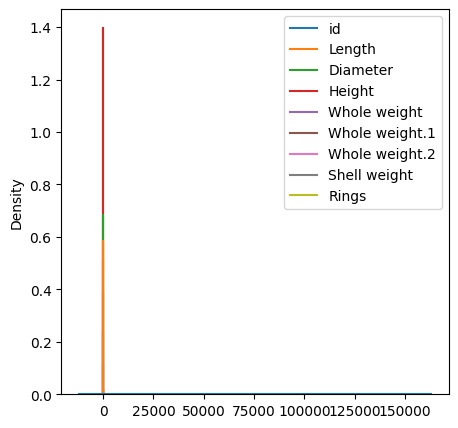

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

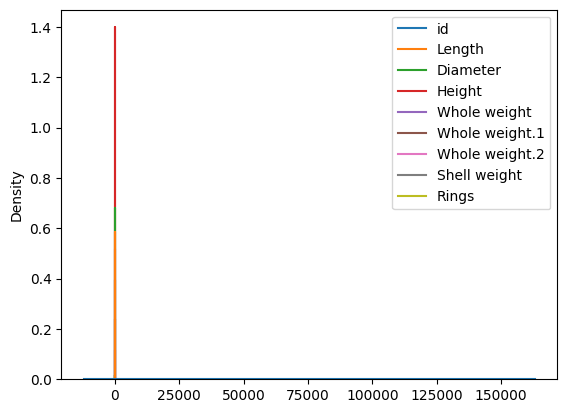

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

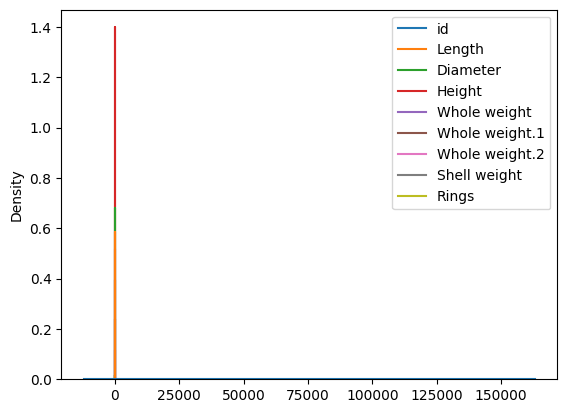

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

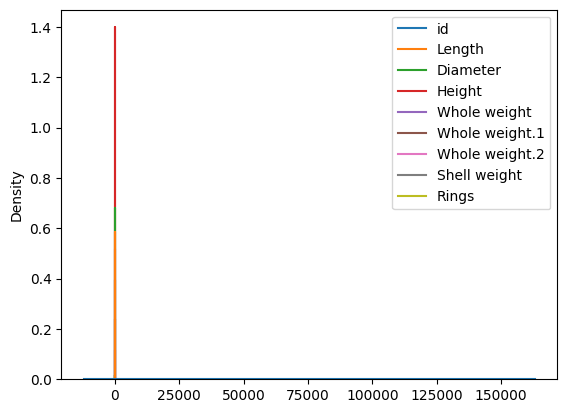

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

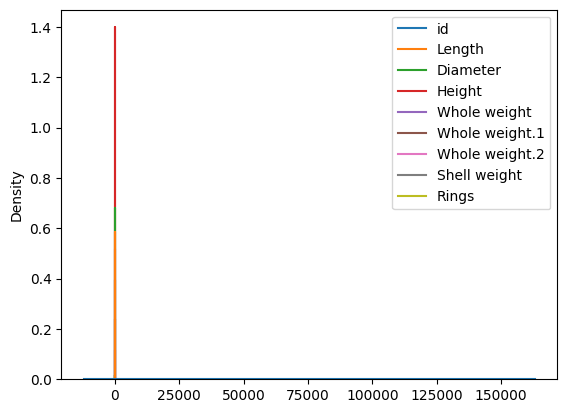

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

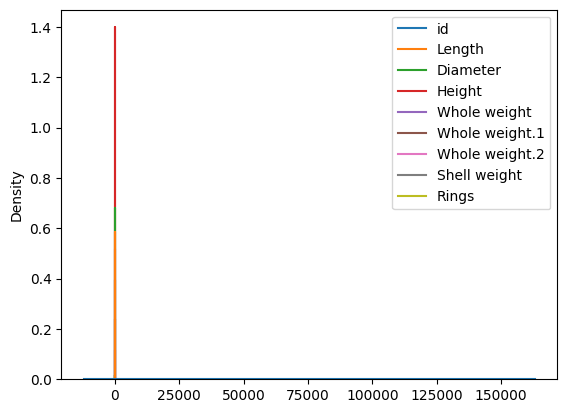

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

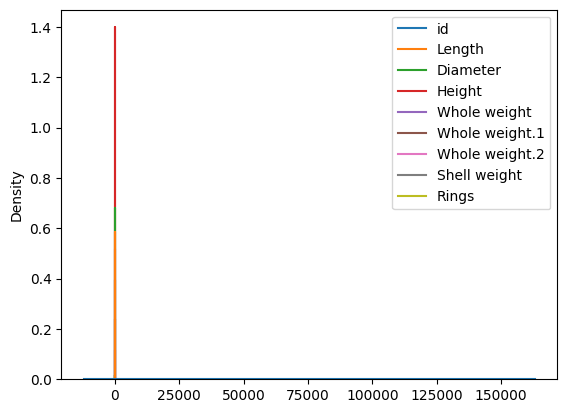

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

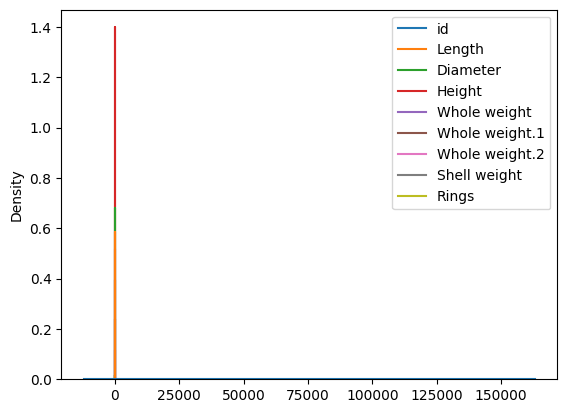

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

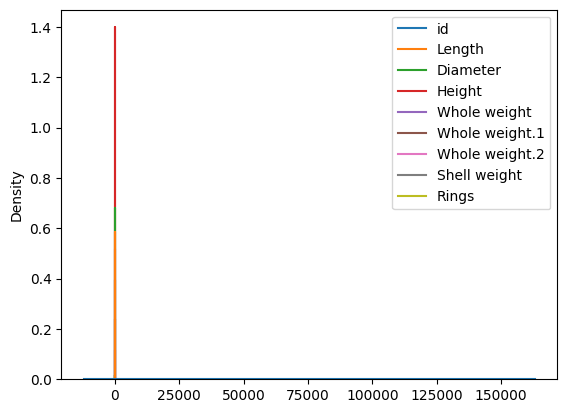

In [31]:
plt.figure(figsize=(5,5))
x = 1
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.kdeplot(data=combined)
    print('\n')
    plt.show()

In [34]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm

In [35]:
import warnings
warnings.filterwarnings('ignore')

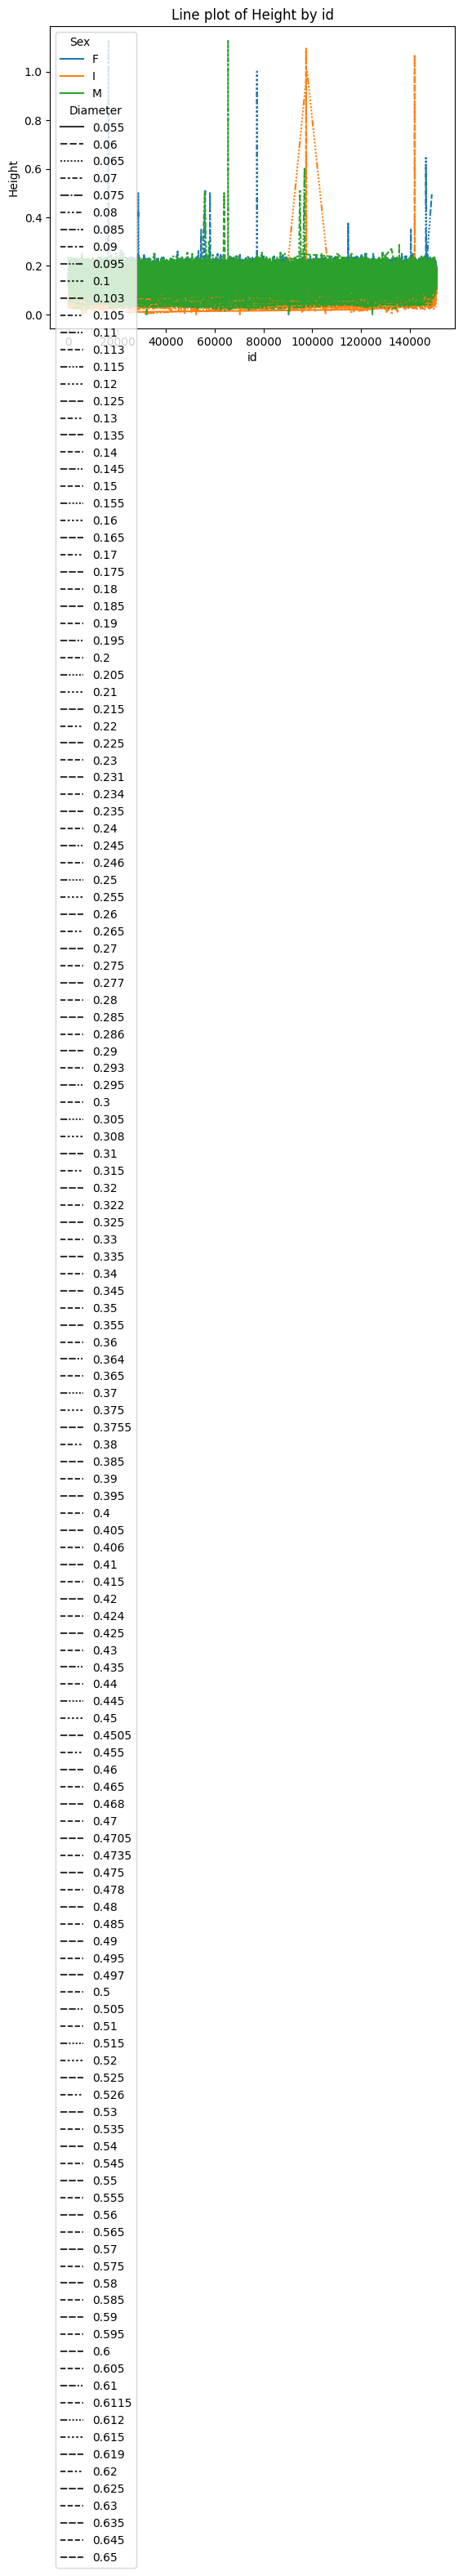

In [37]:
sns.lineplot(x='id', y='Height', data=combined, hue='Sex', style='Diameter')
plt.title("Line plot of Height by id")
plt.show()

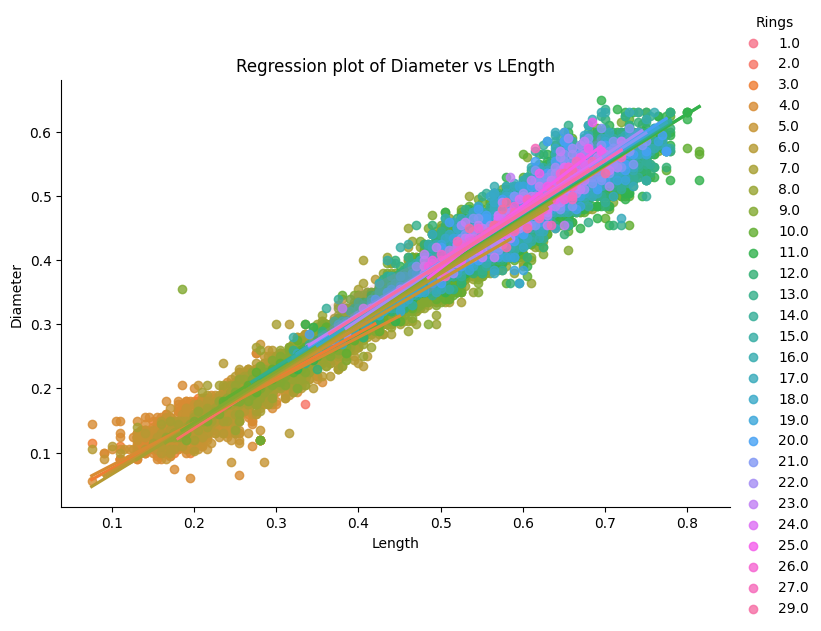

In [40]:
sns.lmplot(x='Length',y='Diameter',data=combined,hue='Rings',height=5,aspect=1.5)
plt.title("Regression plot of Diameter vs LEngth")
plt.show()

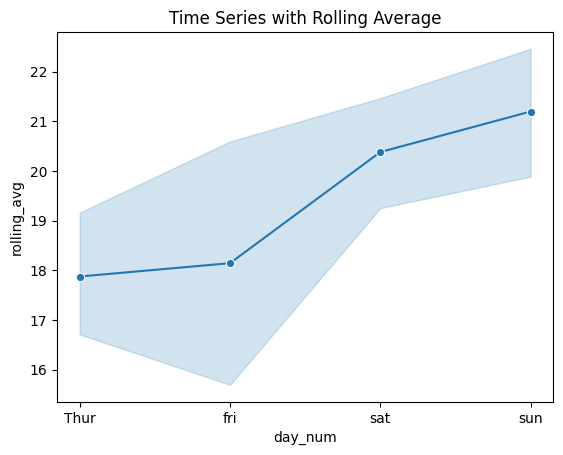

In [41]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg']= df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips, marker='o')
plt.xticks(ticks=[0,1,2,3], labels=['Thur','fri','sat','sun'])
plt.title('Time Series with Rolling Average')
plt.show()